<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/ProcessQuestionsSeparatelyThenAggregate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [28]:
import matplotlib
import os
import pandas
import sklearn
import sys
import transformers

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 509, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 509 (delta 91), reused 66 (delta 31), pack-reused 360 (from 1)
Receiving objects: 100% (509/509), 1.02 MiB | 20.08 MiB/s, done.
Resolving deltas: 100% (300/300), done.


In [39]:
from innoprod.plotting_tools import rand_jitter
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps

In [6]:
data = get_sheet_dfs()
roadmaps_df = wrangle_roadmaps(data['Roadmaps'])

/content/digi-inno-road-prod/innoprod/wrangling/wrangling_tools.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[mask] = new_value


In [7]:
qual_cols = [
    'Summary review of Edge Digital diagnostic report & current state and key improvement areas',
    'What are the internal barriers to growth? How do you intend to finance future growth? Are there sufficient leadership and management skills in the business to achieve your growth? What opportunities do you have to expand into new markets?',
    'Details of any existing Digital Strategy', # Check: Rob added in on 21st May
    'Level of current Strategic Digital Skills/knowledge in the business',
    'Level of current Technical Digital Skills/knowledge in the business',
    'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples',
    'Summary of the identified problems, including Gap Analysis'
]

In [8]:
DRS_levels = [
    "The business has no vision for driving growth with digital technologies, and is not supporting workers to investigate opportunities.", # 1
    "Workers are aware of the potential for digital technologies and are supported by the business to experiment with local trials.", # 2
    "The business is learning from local trials of digital technologies and leaders are investigating the business case.", # 3
    "The business has a strategic vision for digital transformation, the business case is agreed and implementation is underway.", # 4
    "Workers are engaged in digital transformation and the business is starting to achieve business case benefits.", # 5
    "Digital technologies are driving continuous improvement in key aspects of operational performance including supply chain and customer services.", # 6
    "Innovation with digital technologies is part of the culture of the business and is driving continuous improvement in all aspects.", # 7
    "Increasing adoption of digital technologies is sustained by reinvestment of related profits and continuous renewal of the business case.", # 8
    "Digital technologies are driving optimized productivity and competitiveness for the business and its partners.", # 9
]

In [9]:
model_name = "facebook/bart-large-mnli"
# model_name = "google-bert/bert-base-uncased"
# model_name = "pborchert/BusinessBERT"
classifier = transformers.pipeline("zero-shot-classification", model=model_name)
hypothesis_template = ("This company's digital readiness level is best described as: {}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Sandpit

In [10]:
single_firm_responses = [q + ". " + r for q,r in zip(qual_cols, roadmaps_df[qual_cols].iloc[156].to_list())]
# single_firm_responses

In [11]:
results = classifier(
      single_firm_responses,
      candidate_labels=DRS_levels,
      hypothesis_template=hypothesis_template
)
# results

# Null results

In [12]:
null_results = classifier(
      qual_cols,
      candidate_labels=DRS_levels,
      hypothesis_template=hypothesis_template
)
# null_results

In [13]:
def get_drs_level_score(row, drs_level):
    drs_label = DRS_levels[drs_level - 1]
    index = row["labels"].index(drs_label)
    return row["scores"][index]

def results_to_df(results, null_results=None):
  results_df = pandas.DataFrame(results)
  for i in range(1,len(DRS_levels)+1):
    col = f"DRS:{i}"
    drs_scores = results_df.apply(lambda row: get_drs_level_score(row, i), axis=1)
    if null_results is not None:
      drs_scores = drs_scores - null_results[col]
    results_df[col] = drs_scores

  results_df['Top DRS'] = results_df.filter(regex=r"DRS\:\d+").idxmax(axis=1).apply(lambda x: int(x.split(":")[1]))
  results_df['Confidence'] = results_df.filter(regex=r"DRS\:\d+").apply(lambda row: row.nlargest(1).values[0] - row.nlargest(2).values[-1], axis=1)
  return results_df.drop(columns=['labels', 'scores'])

null_results_df = results_to_df(null_results)
# null_results_df

In [14]:
results_df = results_to_df(results, null_results=null_results_df)
# results_df

In [15]:
def get_question_from_sequence(sequence):
  for q in qual_cols:
    if sequence.startswith(q):
      return q
  return None

results_df['question'] = results_df['sequence'].apply(get_question_from_sequence)
results_df

def get_most_confident_prediction(results, null_df):
  results_df = results_to_df(results, null_df)
  singlemost_idx = results_df['Confidence'].idxmax()
  singlemost_drs = int(results_df.iloc[singlemost_idx]['Top DRS'])
  singlemost_question = get_question_from_sequence(results_df.iloc[singlemost_idx]['sequence'])
  singlemost_drs_confidence = results_df['Confidence'].max()
  conf_df = results_df[['Top DRS', 'Confidence']].groupby('Top DRS').sum()
  combined_prediction = conf_df.idxmax(axis=0).tolist()[0]
  combined_prediction_confidence = conf_df['Confidence'].sort_values(ascending=False).to_list()
  combined_prediction_confidence = combined_prediction_confidence[0] - combined_prediction_confidence[1]
  return {
      'singlemost_drs': singlemost_drs,
      'singlemost_question': singlemost_question,
      'singlemost_drs_confidence': singlemost_drs_confidence,
      'combined_prediction': combined_prediction,
      'combined_prediction_confidence': combined_prediction_confidence
  }

get_most_confident_prediction(results, null_results_df)

{'singlemost_drs': 1,
 'singlemost_question': 'Details of any existing Digital Strategy',
 'singlemost_drs_confidence': 0.6254346240311861,
 'combined_prediction': 1,
 'combined_prediction_confidence': 0.5112061370164156}

In [16]:
# all_seq is a list of lists: one list for each firm, and an item for each question-response within each sub-list
all_seq = roadmaps_df.apply(lambda row: [q + ". " + r for q,r in zip(qual_cols, row[qual_cols].to_list())], axis=1).to_list()
all_seq = [seq for firm_seqs in all_seq for seq in firm_seqs]
len(all_seq)


1540

In [17]:
pipeline_preds = classifier(
      all_seq,
      candidate_labels=DRS_levels,
      hypothesis_template=hypothesis_template
)

In [18]:
def unflatten_list(l, sublist_len):
  return [l[i:i+sublist_len] for i in range(0, len(l), sublist_len)]
pipeline_preds = unflatten_list(pipeline_preds, len(qual_cols))
len(pipeline_preds)

220

In [19]:
predictions = [get_most_confident_prediction(results, null_results_df) for results in pipeline_preds]
# predictions

In [22]:
roadmaps_df = pandas.concat([roadmaps_df, pandas.DataFrame.from_dict(predictions)], axis=1)

In [23]:
roadmaps_df['singlemost_question'].value_counts()

,count
singlemost_question,
Summary review of Edge Digital diagnostic report & current state and key improvement areas,88
Details of any existing Digital Strategy,36
"Summary of the identified problems, including Gap Analysis",33
Level of current Strategic Digital Skills/knowledge in the business,22
What are the internal barriers to growth? How do you intend to finance future growth? Are there sufficient leadership and management skills in the business to achieve your growth? What opportunities do you have to expand into new markets?,18
"Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples",16
Level of current Technical Digital Skills/knowledge in the business,7


In [26]:
roadmaps_df[['Current Digital Readiness Score (refer to PAS:1040)', 'singlemost_drs', 'combined_prediction']].dropna().corr()

,Current Digital Readiness Score (refer to PAS:1040),singlemost_drs,combined_prediction
Current Digital Readiness Score (refer to PAS:1040),1.000000,0.194596,0.176127
singlemost_drs,0.194596,1.000000,0.892850
combined_prediction,0.176127,0.892850,1.000000


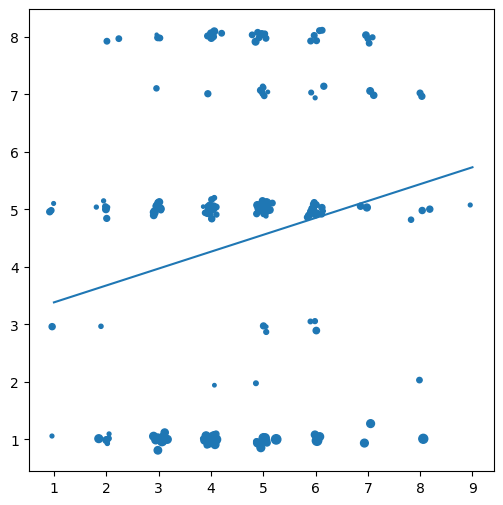

In [63]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
x_col = 'Current Digital Readiness Score (refer to PAS:1040)'
y_col = 'singlemost_drs'
size_col = 'singlemost_drs_confidence'

X = roadmaps_df[[x_col, y_col, size_col]].dropna()[[x_col]].to_numpy().reshape(-1, 1)
Y = roadmaps_df[[x_col, y_col, size_col]].dropna()[[y_col]].to_numpy().reshape(-1, 1)
S = roadmaps_df[[x_col, y_col, size_col]].dropna()[[size_col]].to_numpy().reshape(-1, 1)

lr_model = sklearn.linear_model.LinearRegression()
lr_model.fit(X, Y)

intercept = float(lr_model.intercept_[0])
coef = float(lr_model.coef_[0][0])

ax.scatter(rand_jitter(X), rand_jitter(Y), s=S*50)
ax.plot([1,9], [intercept+coef, intercept+9*coef])
ax.set_xlabel('Expert-assigned DRS')
ax.set_ylabel('Singlemost predicted DRS')

In [48]:
lr_model.score(X, Y)

0.037867626569250024

Text(0, 0.5, 'Combined prediction DRS')

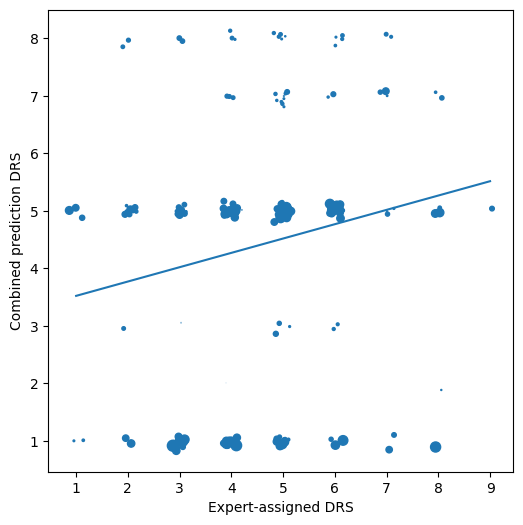

In [65]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
x_col = 'Current Digital Readiness Score (refer to PAS:1040)'
y_col = 'combined_prediction'
size_col = 'combined_prediction_confidence'

X = roadmaps_df[[x_col, y_col, size_col]].dropna()[[x_col]].to_numpy().reshape(-1, 1)
Y = roadmaps_df[[x_col, y_col, size_col]].dropna()[[y_col]].to_numpy().reshape(-1, 1)
S = roadmaps_df[[x_col, y_col, size_col]].dropna()[[size_col]].to_numpy().reshape(-1, 1)

lr_model = sklearn.linear_model.LinearRegression()
lr_model.fit(X, Y)

intercept = float(lr_model.intercept_[0])
coef = float(lr_model.coef_[0][0])

ax.scatter(rand_jitter(X), rand_jitter(Y), s=S*50)
ax.plot([1,9], [intercept+coef, intercept+9*coef])
ax.set_xlabel('Expert-assigned DRS')
ax.set_ylabel('Combined prediction DRS')